In [6]:
import networkx as nx
import random
import warnings
import pandas as pd
from tqdm.auto import tqdm
from collections import Counter, defaultdict
from datetime import datetime, timedelta
import os
import joblib
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')

 ## DATASET + GRAFO CON AUTOMA DETERMINISTICO


In [7]:
interval_labeling = pd.read_csv("intervalli_glucosio.csv", delimiter=',')
df = pd.DataFrame(interval_labeling)
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])
df["duration"] = ((df["end_time"] - df["start_time"]).dt.total_seconds() / 60).round(2)
arr = []
for index, row in df.iterrows():
    arr.append((row['label'], row['duration']))

seq = arr

G = nx.DiGraph()

for i in range(len(seq) - 1):
    src, dur_src = seq[i]
    dst, dur_dst = seq[i + 1]
    if G.has_edge(src, dst):
        G[src][dst]["count"] += 1
        G[src][dst]["durations"].append(dur_dst)
    else:
        G.add_edge(src, dst, count=1, durations=[dur_dst])


## EVENTI SU AUTOMA DETERMINISTICO

In [8]:
def most_n_frequent_events(seq, n=3):
    ngrams = defaultdict(lambda: {'count': 0, 'durations': []})
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        #durations = [s[1] for s in seq[i:i+n]]
        ngrams[labels]['count'] += 1
        #ngrams[labels]['durations'].append(durations)
    return ngrams


# --- Calcolo media durate per ogni transizione ---
for u, v, data in G.edges(data=True):
    data["mean_duration"] = sum(data["durations"]) / len(data["durations"])

# --- Calcolo delle probabilità di transizione ---
for u in G.nodes():
    total = sum(G[u][v]["count"] for v in G.successors(u))
    for v in G.successors(u):
        if total > 0:
            G[u][v]["prob"] = G[u][v]["count"] / total
        else:
            G[u][v]["prob"] = 0.0  # fallback se nessuna uscita

# --- Stampa riepilogativa delle transizioni ---
print("\n Modello probabilistico delle transizioni:\n")
for u in G.nodes():
    successors = list(G.successors(u))
    if not successors:
        print(f"{u} → [nessuna uscita]")
        continue
    print(f"\nDa stato '{u}' posso passare a:")
    for v in successors:
        prob = G[u][v]["prob"]
        mean_dur = round(G[u][v]["mean_duration"], 2)
        count = G[u][v]["count"]
        print(f"  ↳ {v:<16} | Probabilità: {prob:.2f} | Count: {count:<3} | Durata media: {mean_dur} min")

# --- Eventi più frequenti ---
events = most_n_frequent_events(seq, 4)
print("\n Esempio di 4 pattern più frequenti:")
for k, v in sorted(events.items(), key=lambda x: x[1]['count'], reverse=True)[:10]:
    print(f"{k} | count={v['count']}")


 Modello probabilistico delle transizioni:


Da stato 'high' posso passare a:
  ↳ normal           | Probabilità: 0.83 | Count: 59  | Durata media: 140.17 min
  ↳ extremely_high   | Probabilità: 0.17 | Count: 12  | Durata media: 70.0 min

Da stato 'normal' posso passare a:
  ↳ high             | Probabilità: 0.65 | Count: 58  | Durata media: 33.19 min
  ↳ low              | Probabilità: 0.35 | Count: 31  | Durata media: 16.29 min

Da stato 'extremely_high' posso passare a:
  ↳ high             | Probabilità: 1.00 | Count: 12  | Durata media: 28.33 min

Da stato 'low' posso passare a:
  ↳ normal           | Probabilità: 0.91 | Count: 31  | Durata media: 208.71 min
  ↳ extremely_low    | Probabilità: 0.09 | Count: 3   | Durata media: 5.01 min

Da stato 'extremely_low' posso passare a:
  ↳ low              | Probabilità: 1.00 | Count: 3   | Durata media: 0.0 min

 Esempio di 4 pattern più frequenti:
('normal', 'high', 'normal', 'high') | count=41
('high', 'normal', 'high', 'normal') | co

## CREAZIONE SEQUENZE REALISTICHE E RANDOMICHE

In [9]:
def simulate_random_sequence_realistic(
    G,
    total_minutes=10000,
    balanced=False,
    forced_length=None,
    noise_mode=False,
    borderline=False
):
    """
    Funzione MASTER per generare sequenze CGM realistiche.

    Parametri:
    - balanced=True  → target 1/3 verde, 1/3 giallo, 1/3 rosso
    - forced_length=N → lunghezza fissa in minuti
    - noise_mode=True → rumore tipo CGM
    - borderline=True → valori vicini alle soglie
    """

    from collections import defaultdict
    import numpy as np
    import random

    # Durata fissa opzionale
    if forced_length is not None:
        total_minutes = forced_length

    state_order = {
        "extremely_low": -2,
        "low": -1,
        "normal": 0,
        "high": 1,
        "extremely_high": 2
    }

    # Glucosio: range normale o borderline
    if borderline:
        glucose_ranges = {
            "extremely_low": (50, 60),
            "low": (75, 85),
            "normal": (110, 130),
            "high": (175, 185),
            "extremely_high": (240, 260)
        }
    else:
        glucose_ranges = {
            "extremely_low": (40, 55),
            "low": (56, 80),
            "normal": (81, 179),
            "high": (180, 249),
            "extremely_high": (250, 350)
        }

    # TARGET COLOR
    if balanced:
        target_color = random.choices(
            ["verde", "giallo", "rosso"],
            weights=[0.4, 0.3, 0.3],
            k=1
        )[0]
    else:
        target_color = random.choices(
            ["verde", "giallo", "rosso"],
            weights=[0.6, 0.3, 0.1],
            k=1
        )[0]

    # Probabilità base per transizioni
    if target_color == "verde":
        base_probs = {"normal": 0.8, "high": 0.1, "low": 0.07, "extreme": 0.03}
    elif target_color == "giallo":
        base_probs = {"normal": 0.5, "high": 0.25, "low": 0.2, "extreme": 0.05}
    else:
        base_probs = {"normal": 0.2, "high": 0.4, "low": 0.3, "extreme": 0.1}

    duration_scale = 1.2
    noise_factor = 0.5

    state = "normal"
    seq = []
    tot_gluc = 0
    tot_time = 0
    elapsed = 0
    counts = defaultdict(int)

    # LOOP principale
    while elapsed < total_minutes:
        successors = list(G.successors(state))
        if not successors:
            state = random.choice(list(G.nodes))
            successors = list(G.successors(state))
            if not successors:
                continue

        pulse = 1 + np.sin(elapsed / 5000) * random.uniform(-0.2, 0.2)
        succ_probs = []

        for s in successors:
            if s == "normal":
                base = base_probs["normal"]
            elif abs(state_order[s]) == 1:
                base = base_probs["high"] if state_order[s] > 0 else base_probs["low"]
            else:
                base = base_probs["extreme"]

            base *= random.uniform(0.8, 1.2) * pulse
            base *= 1 / (1 + counts[s] / 60)
            succ_probs.append(base)

        succ_probs = np.array(succ_probs)
        succ_probs /= succ_probs.sum()
        next_state = random.choices(successors, succ_probs)[0]

        # Durata intervallo
        mean_dur = G[state][next_state].get("mean_duration", 30)
        factor = duration_scale * (1.3 - 0.25 * abs(state_order[next_state]))
        dur = np.random.normal(mean_dur * factor, mean_dur * noise_factor)
        dur = np.clip(dur, 1, 240)

        # Glucosio
        gmin, gmax = glucose_ranges[next_state]
        glucose_value = random.uniform(gmin, gmax)

        # Rumore CGM
        if noise_mode:
            glucose_value += np.random.normal(0, 8)
            glucose_value = max(40, min(glucose_value, 400))

        seq.append((next_state, round(dur, 1), round(glucose_value, 1)))
        tot_gluc += glucose_value * dur
        tot_time += dur
        counts[next_state] += 1
        state = next_state
        elapsed += dur

    # Calcolo GMI
    avg_gluc = tot_gluc / tot_time
    gmi = 3.31 + 0.02392 * avg_gluc

    if gmi < 7:
        gmi_color = "🟢 Verde"
    elif 7 <= gmi <= 8:
        gmi_color = "🟡 Giallo"
    else:
        gmi_color = "🔴 Rosso"

    # Colore effettivo tramite algoritmo
    true_color = analyze_simulate_sequence_compact(seq)[0]

    return seq, true_color, gmi, avg_gluc, gmi_color


def simulate_sequence_with_duration(G, start="normal", steps=100, step_minutes=5):
    """
    Simula sequenze Markov con durate realistiche e step_minutes per letture.
    - Evita transizioni duplicate consecutive (normal->normal non viene generato)
    - Le letture successive dello stesso stato sono aggregate
    - Le glicemie cambiano gradualmente con random walk realistico
    """
    state = start
    seq = []

    glucose_ranges = {
        "extremely_low": (40, 55),
        "low": (56, 80),
        "normal": (81, 179),
        "high": (180, 249),
        "extremely_high": (250, 350)
    }

    prev_glucose = np.random.uniform(*glucose_ranges[state])
    prev_state_in_seq = None

    for _ in range(steps):
        # Successori diversi dallo stato corrente
        successors = [s for s in G.successors(state) if s != state]
        if not successors:
            successors = [state]  # fallback: resta nello stesso stato

        probs = [G[state][s]["prob"] for s in successors]
        next_state = random.choices(successors, probs)[0]

        # Determina durata dello stato
        data = G[state][next_state]
        if "mean_duration" in data:
            mean_dur = data["mean_duration"]
            dur = max(step_minutes, np.random.normal(mean_dur, mean_dur * 0.3))
        elif "durations" in data and len(data["durations"]) > 0:
            dur = random.choice(data["durations"])
        else:
            dur = random.uniform(5, 15)

        # Numero di letture in step_minutes
        num_steps = max(1, int(dur / step_minutes))
        gmin, gmax = glucose_ranges[next_state]

        # Random walk e aggregazione letture consecutive
        for _ in range(num_steps):
            delta = np.random.uniform(-2, 2)  # variazione graduale
            gluc = max(gmin, min(gmax, prev_glucose + delta))

            if prev_state_in_seq == next_state and len(seq) > 0:
                last_state, last_dur, last_gluc = seq[-1]
                seq[-1] = (last_state, last_dur + step_minutes, gluc)
            else:
                seq.append((next_state, step_minutes, round(gluc, 0)))
                prev_state_in_seq = next_state

            prev_glucose = gluc

        state = next_state

    return seq


Sequenza simulata: [('low', 15, 80), ('normal', 165, 81.4113232489359), ('low', 15, 78.46125404822692), ('normal', 165, 85.48685179313674), ('low', 20, 77.12920702415454), ('normal', 165, 82.53380332609926), ('high', 10, 180), ('normal', 135, 177.50136725441928), ('high', 45, 182.47079460144707), ('normal', 185, 176.79331593217023), ('high', 50, 182.94398878762854), ('normal', 185, 175.0975705732943), ('high', 45, 183.17849946898951), ('normal', 130, 173.84892089532502), ('high', 35, 185.6445155392966), ('normal', 140, 179), ('high', 25, 183.82879375545343), ('normal', 180, 179), ('low', 5, 80), ('normal', 185, 90.42912365734519), ('low', 10, 80), ('extremely_low', 5, 55), ('low', 5, 56), ('normal', 255, 101.50692668977781), ('low', 5, 80), ('normal', 285, 89.74471934956459), ('high', 35, 180), ('extremely_high', 65, 250.9450680532229), ('high', 25, 249), ('normal', 155, 174.38675975917988), ('high', 45, 180), ('normal', 180, 177.7297220613667), ('high', 30, 180), ('normal', 85, 179),

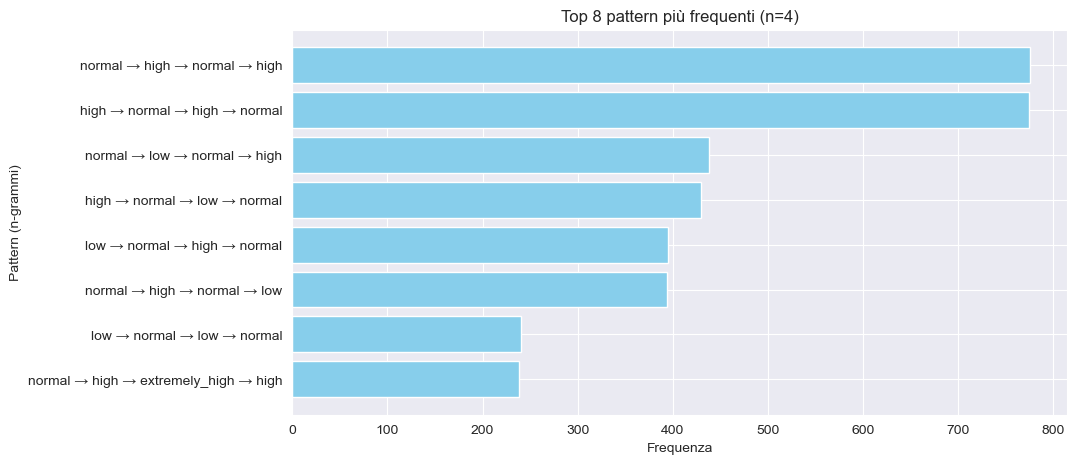

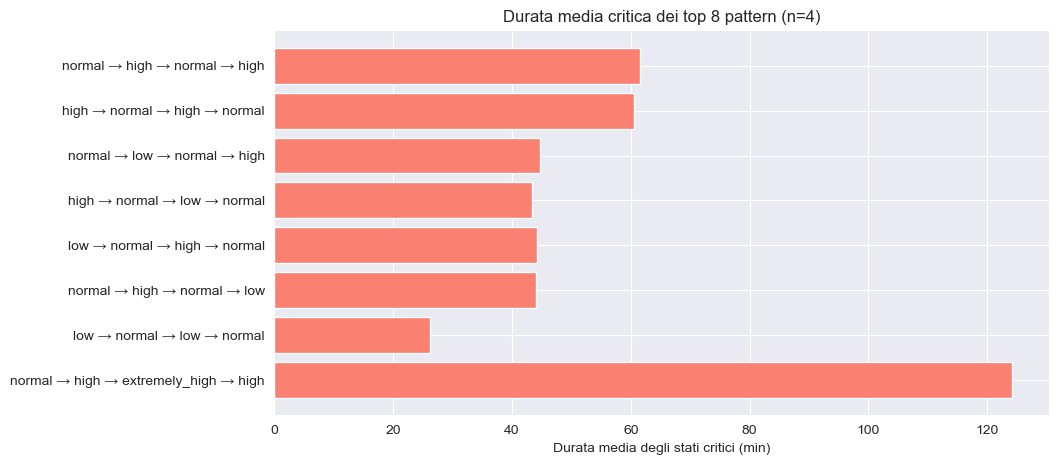

In [10]:
# --- Funzione per estrarre n-grammi con durate ---
def extract_ngrams(seq, n=3):
    ngrams = defaultdict(lambda: {'count': 0, 'durations': []})
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        durations = [s[1] for s in seq[i:i + n]]
        ngrams[labels]['count'] += 1
        ngrams[labels]['durations'].append(durations)
    return ngrams


# --- Analisi pattern frequenti e rari ---
def analyze_patterns_labels(seq, n=3, top_k=5):
    ngrams = defaultdict(int)
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        ngrams[labels] += 1

    results_sorted = sorted(ngrams.items(), key=lambda x: x[1], reverse=True)

    print(f"\nTop {top_k} pattern più frequenti:")
    for labels, count in results_sorted[:top_k]:
        print(f"Pattern {labels} | count={count}")

    print(f"\nTop {top_k} pattern più rari:")
    for labels, count in results_sorted[-top_k:]:
        print(f"Pattern {labels} | count={count}")


# --- Grafico top pattern frequenti ---
def plot_top_patterns(seq, n=3, top_k=10):
    ngrams = defaultdict(int)
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        ngrams[labels] += 1

    results_sorted = sorted(ngrams.items(), key=lambda x: x[1], reverse=True)[:top_k]

    labels = [' → '.join(r[0]) for r in results_sorted]
    counts = [r[1] for r in results_sorted]

    plt.figure(figsize=(10, 5))
    plt.barh(labels, counts, color='skyblue')
    plt.xlabel("Frequenza")
    plt.ylabel("Pattern (n-grammi)")
    plt.title(f"Top {top_k} pattern più frequenti (n={n})")
    plt.gca().invert_yaxis()
    plt.show()


# --- Grafico durata media dei pattern ---
def plot_mean_critical_duration_patterns(seq, n=3, top_k=10):
    critical_states = {"high", "low", "extremely_high", "extremely_low"}
    ngrams = extract_ngrams(seq, n=n)
    results = []

    for labels, data in ngrams.items():
        # calcola durata solo degli stati critici
        critical_durations = []
        for d in data['durations']:
            dur = sum(d[i] for i, s in enumerate(labels) if s in critical_states)
            critical_durations.append(dur)
        mean_critical = sum(critical_durations) / len(critical_durations)
        results.append((' → '.join(labels), mean_critical, data['count']))

    results_sorted = sorted(results, key=lambda x: x[2], reverse=True)[:top_k]

    plt.figure(figsize=(10, 5))
    plt.barh([r[0] for r in results_sorted], [r[1] for r in results_sorted], color='salmon')
    plt.xlabel("Durata media degli stati critici (min)")
    plt.title(f"Durata media critica dei top {top_k} pattern (n={n})")
    plt.gca().invert_yaxis()
    plt.show()


# --- Visualizzazione grafo probabilistico ---
def plot_probabilistic_graph(G):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, arrows=True)
    edge_labels = {(u, v): f"{data['prob']:.2f}" for u, v, data in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Modello probabilistico delle transizioni glicemiche")
    plt.show()


# sim_seq = sequenza simulata con durate
sim_seq = simulate_sequence_with_duration(G, start="normal", steps=5000)

print("\nSequenza simulata:", sim_seq)

# 1 Analisi pattern frequenti e rari
analyze_patterns_labels(sim_seq, n=4, top_k=5)

# 2 Grafico pattern più frequenti
plot_top_patterns(sim_seq, n=4, top_k=8)

# 3 Grafico durata media dei pattern
plot_mean_critical_duration_patterns(sim_seq, n=4, top_k=8)

# 4 Visualizzazione grafo probabilistico
#plot_probabilistic_graph(G)


## Confronto empirico tra dati reali e simulati



=== Confronto Distribuzione Stati ===
     Stato |  Reale (#)  Reale (%) | Simulato (#) Simulato (%)
--------------------------------------------------------------
extremely_high |         12       5.71% |          298         5.96%
extremely_low |          3       1.43% |           64         1.28%
      high |         71      33.81% |         1706        34.12%
       low |         34      16.19% |          794        15.88%
    normal |         90      42.86% |         2138        42.76%
--------------------------------------------------------------
    Totale |        210            |         5000

=== Confronto Distribuzione Transizioni ===
         Transizione |  Reale (#)  Reale (%) | Simulato (#) Simulato (%)
------------------------------------------------------------------------------
extremely_high → high |         12       5.74% |          298         5.96%
 extremely_low → low |          3       1.44% |           64         1.28%
high → extremely_high |         12       5

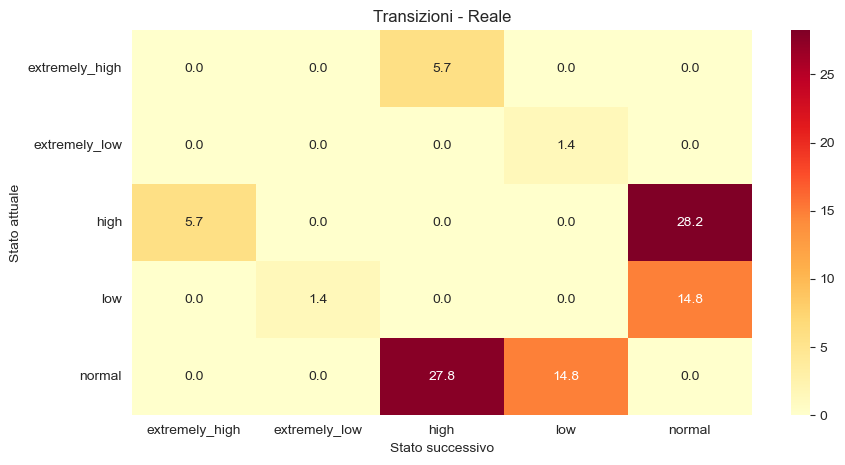

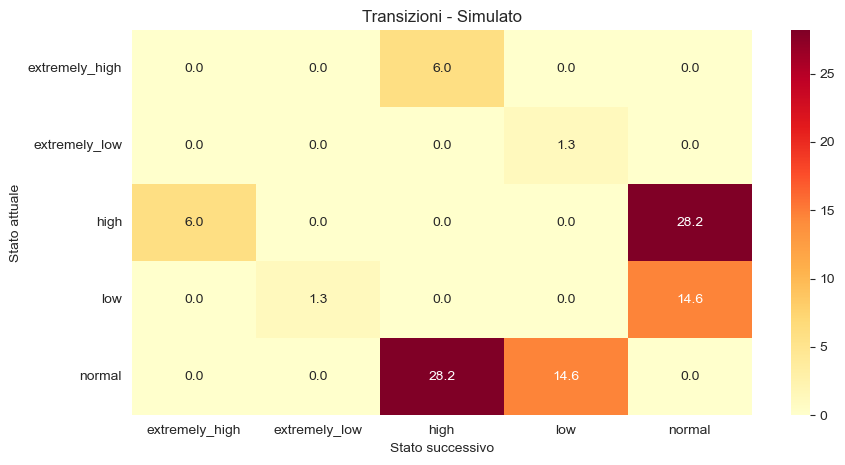

In [11]:
def state_distribution_comparison(real_seq, sim_seq):
    # Conta le frequenze
    def calc_dist(seq):
        states = [s[0] for s in seq]
        counts = Counter(states)
        total = sum(counts.values())
        return {state: (count, count / total * 100) for state, count in counts.items()}, total

    real_dist, real_total = calc_dist(real_seq)
    sim_dist, sim_total = calc_dist(sim_seq)

    all_states = sorted(set(real_dist.keys()) | set(sim_dist.keys()))

    print("\n=== Confronto Distribuzione Stati ===")
    print(f"{'Stato':>10} | {'Reale (#)':>10} {'Reale (%)':>10} | {'Simulato (#)':>12} {'Simulato (%)':>12}")
    print("-" * 62)
    for state in all_states:
        real_count, real_perc = real_dist.get(state, (0, 0))
        sim_count, sim_perc = sim_dist.get(state, (0, 0))
        print(f"{state:>10} | {real_count:10d} {real_perc:10.2f}% | {sim_count:12d} {sim_perc:12.2f}%")
    print("-" * 62)
    print(f"{'Totale':>10} | {real_total:10d}{'':>11} | {sim_total:12d}")


def transition_distribution_comparison(real_seq, sim_seq):
    def calc_dist(seq):
        transitions = [(seq[i][0], seq[i + 1][0]) for i in range(len(seq) - 1)]
        counts = Counter(transitions)
        total = sum(counts.values())
        return {t: (c, c / total * 100) for t, c in counts.items()}, total

    real_dist, real_total = calc_dist(real_seq)
    sim_dist, sim_total = calc_dist(sim_seq)

    all_transitions = sorted(set(real_dist.keys()) | set(sim_dist.keys()))

    print("\n=== Confronto Distribuzione Transizioni ===")
    print(f"{'Transizione':>20} | {'Reale (#)':>10} {'Reale (%)':>10} | {'Simulato (#)':>12} {'Simulato (%)':>12}")
    print("-" * 78)
    for t in all_transitions:
        real_count, real_perc = real_dist.get(t, (0, 0))
        sim_count, sim_perc = sim_dist.get(t, (0, 0))
        tr_label = f"{t[0]} → {t[1]}"
        print(f"{tr_label:>20} | {real_count:10d} {real_perc:10.2f}% | {sim_count:12d} {sim_perc:12.2f}%")
    print("-" * 78)
    print(f"{'Totale':>20} | {real_total:10d}{'':>11} | {sim_total:12d}")


def average_duration_per_state(real_seq, sim_seq):
    # Calcolo media per stato, gestendo tuple di 2 o 3 elementi
    def calc_avg(seq):
        durations_per_state = defaultdict(list)
        for item in seq:
            if len(item) == 3:
                state, dur, _ = item
            elif len(item) == 2:
                state, dur = item
            else:
                raise ValueError(f"Unexpected tuple length {len(item)} in sequence: {item}")
            durations_per_state[state].append(dur)
        avg_per_state = {state: sum(durs) / len(durs) for state, durs in durations_per_state.items()}
        return avg_per_state

    real_avg = calc_avg(real_seq)
    sim_avg = calc_avg(sim_seq)

    all_states = sorted(set(real_avg.keys()) | set(sim_avg.keys()))

    print("\n=== Durata media per stato (minuti) ===")
    print(f"{'Stato':>15} | {'Reale':>10} | {'Simulato':>10}")
    print("-" * 40)
    for state in all_states:
        real_dur = real_avg.get(state, 0)
        sim_dur = sim_avg.get(state, 0)
        print(f"{state:>15} | {real_dur:10.2f} | {sim_dur:10.2f}")
    print("-" * 40)

def plot_transition_heatmap(real_seq, sim_seq, normalize=True):
    """
    Visualizza una heatmap delle transizioni di stato per sequenze reali e simulate.

    Parametri:
    - real_seq, sim_seq: liste di tuple (state, duration) o (state, duration, glucose)
    - normalize: se True, mostra frequenze relative (%)
    """

    def get_transitions(seq):
        trans = Counter()
        for i in range(len(seq) - 1):
            s1 = seq[i][0]
            s2 = seq[i + 1][0]
            trans[(s1, s2)] += 1
        return trans

    # Transizioni
    real_trans = get_transitions(real_seq)
    sim_trans = get_transitions(sim_seq)

    # Tutti gli stati coinvolti
    all_states = sorted(set([s for s, _ in real_trans.keys()] + [s for _, s in real_trans.keys()] +
                            [s for s, _ in sim_trans.keys()] + [s for _, s in sim_trans.keys()]))

    # Matrice reale
    real_matrix = [[real_trans.get((i, j), 0) for j in all_states] for i in all_states]
    sim_matrix = [[sim_trans.get((i, j), 0) for j in all_states] for i in all_states]

    if normalize:
        # Frequenze relative
        total_real = sum(real_trans.values())
        total_sim = sum(sim_trans.values())
        real_matrix = [[v / total_real * 100 for v in row] for row in real_matrix]
        sim_matrix = [[v / total_sim * 100 for v in row] for row in sim_matrix]

    # Heatmap reale
    plt.figure(figsize=(10, 5))
    sns.heatmap(real_matrix, annot=True, fmt=".1f" if normalize else "d",
                xticklabels=all_states, yticklabels=all_states, cmap="YlOrRd")
    plt.title("Transizioni - Reale")
    plt.xlabel("Stato successivo")
    plt.ylabel("Stato attuale")
    plt.show()

    # Heatmap simulata
    plt.figure(figsize=(10, 5))
    sns.heatmap(sim_matrix, annot=True, fmt=".1f" if normalize else "d",
                xticklabels=all_states, yticklabels=all_states, cmap="YlOrRd")
    plt.title("Transizioni - Simulato")
    plt.xlabel("Stato successivo")
    plt.ylabel("Stato attuale")
    plt.show()


# Esempio d'uso
state_distribution_comparison(seq, sim_seq)
transition_distribution_comparison(seq, sim_seq)
average_duration_per_state(seq, sim_seq)
plot_transition_heatmap(seq, sim_seq, normalize=True)


## Algoritmo per assegnare soglie alle squenze

In [12]:
THRESHOLDS_DURATION = {
    "high": 90,
    "low": 30,
    "extremely_high": 45,
    "extremely_low": 10,
}


def analyze_simulate_sequence_compact(seq, analize_day=None):
    """
    Analisi compatta della sequenza.
    Restituisce solo lo stato finale (🟢🟡🔴) e il numero totale di anomalie.
    """
    if analize_day is None:
        total_minutes = sum(item[1] for item in seq)  # usa sempre il secondo elemento = durata
        analize_day = round(total_minutes / 1440)
    max_minutes = analize_day * 1440
    elapsed = 0

    states = ["extremely_high", "high", "normal", "low", "extremely_low"]
    counts = {s: 0 for s in states}
    durations = {s: 0 for s in states}

    transitions_of_interest = [
        ("normal", "high"), ("normal", "low"),
        ("low", "normal"), ("low", "extremely_low"),
        ("high", "normal"), ("high", "extremely_high"),
        ("extremely_low", "low"), ("extremely_high", "high")
    ]
    transition_counts = {t: 0 for t in transitions_of_interest}

    prev_state = None
    for item in seq:
        state = item[0]
        duration = item[1]

        if prev_state is not None and (prev_state, state) in transition_counts:
            transition_counts[(prev_state, state)] += 1
        prev_state = state
        elapsed += duration
        if elapsed >= max_minutes:
            break
        if state in counts:
            counts[state] += 1
            durations[state] += duration

    average_duration = {s: (durations[s] / counts[s] if counts[s] > 0 else 0) for s in states}

    thresholds_frequency = {
        "high": 3 * analize_day,
        "low": 3 * analize_day,
        "extremely_high": analize_day,
        "extremely_low": analize_day,
    }

    anomalies_frequency = sum(
        counts[s] >= thresholds_frequency.get(s, float('inf'))
        for s in thresholds_frequency
    )
    anomalies_duration = sum(
        average_duration[s] >= THRESHOLDS_DURATION.get(s, float('inf'))
        for s in THRESHOLDS_DURATION
    )
    total_anomalies = anomalies_frequency + anomalies_duration

    if total_anomalies <= 2:
        status = "🟢 Verde"
    elif total_anomalies <= 4:
        status = "🟡 Giallo"
    else:
        status = "🔴 Rosso"

    return status, total_anomalies


def plot_sequence(seq, index=None, status=None):
    """
    Crea un grafico per visualizzare l'evoluzione dello stato nel tempo.
    Compatibile con sequenze (state, duration) o (state, duration, glucose_value)
    """
    state_map = {
        "extremely_low": -2,
        "low": -1,
        "normal": 0,
        "high": 1,
        "extremely_high": 2
    }
    color_map = {
        -2: "#0044cc",  # blu
        -1: "#00aaff",  # azzurro
        0: "#00cc44",  # verde
        1: "#ffcc00",  # giallo
        2: "#ff3300"  # rosso
    }

    times = [0]
    values = [state_map[seq[0][0]] if seq else 0]

    for item in seq:
        state = item[0]
        duration = item[1]
        times.append(times[-1] + duration)
        values.append(state_map[state])

    plt.figure(figsize=(10, 3))
    for i in range(1, len(times)):
        plt.plot(times[i - 1:i + 1], values[i - 1:i + 1], color=color_map[values[i]], linewidth=2)
    plt.yticks([-2, -1, 0, 1, 2], ["ext_low", "low", "normal", "high", "ext_high"])
    plt.xlabel("Tempo (minuti)")
    plt.title(f"Sequenza {index} – Stato finale: {status}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


def generate_and_test_models_compact(number_models=10, total_days=7, show_graph=True):
    total_minutes = total_days * 1440  # conversione giorni → minuti
    results = []

    for i in range(number_models):
        seq, target, gmi, avg_gluc, gmi_color = simulate_random_sequence_realistic(G, total_minutes)
        status, anomalies = analyze_simulate_sequence_compact(seq)
        results.append((status, anomalies, target))

        print(f"Modello {i}: {status}, anomalie: {anomalies}, target: {target}")

        if show_graph:
            plot_sequence(seq, index=i, status=status)

    status_counts = Counter([status for status, _, _ in results])
    anomalies_list = [anomalies for _, anomalies, _ in results]

    summary = {
        "status_counts": status_counts,
        "min_anomalies": min(anomalies_list),
        "max_anomalies": max(anomalies_list),
        "avg_anomalies": sum(anomalies_list) / len(anomalies_list)
    }

    print("\n" + "=" * 60)
    print(" RIEPILOGO DEI MODELLI ".center(60))
    print("=" * 60)
    for s, c in summary["status_counts"].items():
        perc = (c / len(results)) * 100
        print(f"{s}: {c} modelli ({perc:.1f}%)")
    print("-" * 60)
    print(f"Anomalie - min: {summary['min_anomalies']}, "
          f"max: {summary['max_anomalies']}, "
          f"media: {summary['avg_anomalies']:.2f}")
    print("=" * 60)

    return results, summary

## CODICE DI PROVA PER GENERARE ED ETICHETTARE MODELLI

Modello 0: 🟢 Verde, anomalie: 1, target: 🟢 Verde


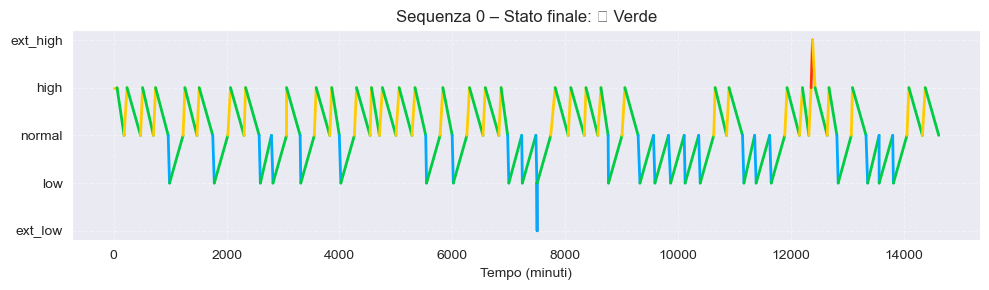

Modello 1: 🟡 Giallo, anomalie: 3, target: 🟡 Giallo


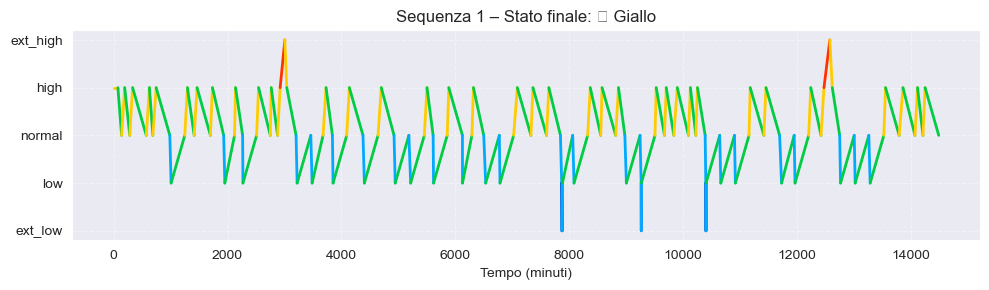

Modello 2: 🟢 Verde, anomalie: 2, target: 🟢 Verde


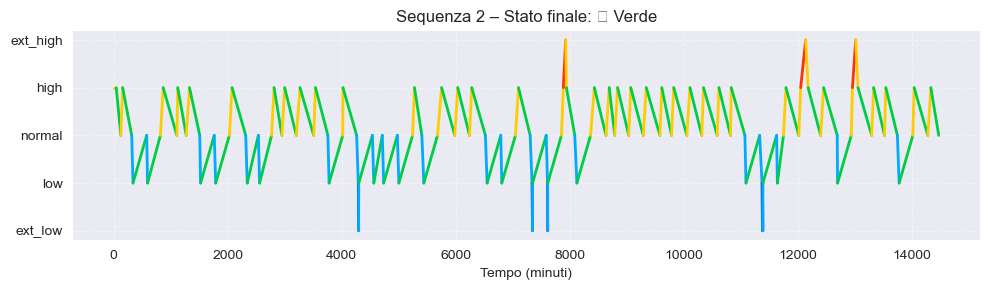


                   RIEPILOGO DEI MODELLI                    
🟢 Verde: 2 modelli (66.7%)
🟡 Giallo: 1 modelli (33.3%)
------------------------------------------------------------
Anomalie - min: 1, max: 3, media: 2.00
Modello 0: 🟢 Verde, anomalie: 1, target simulato: 🟢 Verde
Modello 1: 🟡 Giallo, anomalie: 3, target simulato: 🟡 Giallo
Modello 2: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde

                    RIEPILOGO DEI MODELLI                   
🟢 Verde: 2 modelli (66.7%)
🟡 Giallo: 1 modelli (33.3%)
------------------------------------------------------------
Anomalie - min: 1, max: 3, media: 2.00


In [13]:

results, summary = generate_and_test_models_compact(number_models=3, total_days=10)

for i, (status, anomalies, target) in enumerate(results):
    print(f"Modello {i}: {status}, anomalie: {anomalies}, target simulato: {target}")

print("\n" + "=" * 60)
print(" RIEPILOGO DEI MODELLI".center(60))
print("=" * 60)

for s, c in summary["status_counts"].items():
    perc = (c / len(results)) * 100
    print(f"{s}: {c} modelli ({perc:.1f}%)")

print("-" * 60)
print(f"Anomalie - min: {summary['min_anomalies']}, "
      f"max: {summary['max_anomalies']}, "
      f"media: {summary['avg_anomalies']:.2f}")

if "mode_counts" in summary:
    print("\nModalità globali simulate:")
    for m, c in summary["mode_counts"].items():
        print(f"{m}: {c} modelli ({c / len(results) * 100:.1f}%)")

print("=" * 60)

## ESTRAZIONE FEATURES DA SEQUENZE + GENERAZIONE DI SEQUENZE + GENERAZIONE CSV

In [14]:
def extract_features(sequence, max_minutes=None):
    """
    Estrae feature numeriche da una sequenza per ML, incluse informazioni aggiuntive
    per catturare pattern sottili che l'algoritmo di targeting potrebbe non vedere.

    Parametri:
    - sequence: lista di tuple (state, duration[, glucose])
    - max_minutes: opzionale, limita la sequenza a tot minuti

    Restituisce:
    - dict di feature pronte per ML
    """

    states = ["extremely_low", "low", "normal", "high", "extremely_high"]
    counts = {s: 0 for s in states}
    durations = {s: 0 for s in states}
    transitions_of_interest = [
        ("normal", "high"), ("normal", "low"),
        ("low", "normal"), ("low", "extremely_low"),
        ("high", "normal"), ("high", "extremely_high"),
        ("extremely_low", "low"), ("extremely_high", "high")
    ]
    transition_counts = {t: 0 for t in transitions_of_interest}

    elapsed = 0
    prev_state = None
    glucose_values = []

    for item in sequence:
        # Compatibilità con tuple (state, dur) o (state, dur, glucose)
        if len(item) == 3:
            state, dur, glucose = item
            glucose_values.append(glucose)
        else:
            state, dur = item

        if max_minutes:
            elapsed += dur
            if elapsed > max_minutes:
                break

        counts[state] += 1
        durations[state] += dur

        if prev_state is not None and (prev_state, state) in transition_counts:
            transition_counts[(prev_state, state)] += 1
        prev_state = state

    total_time = sum(durations.values())
    features = {}

    for s in states:
        features[f"perc_time_{s}"] = durations[s] / total_time if total_time > 0 else 0
        features[f"avg_dur_{s}"] = durations[s] / counts[s] if counts[s] > 0 else 0
        features[f"count_{s}"] = counts[s]

    for t, c in transition_counts.items():
        features[f"trans_{t[0]}_{t[1]}"] = c / len(sequence) if len(sequence) > 0 else 0

    if glucose_values:
        deltas = np.diff(glucose_values)
        features["avg_glucose"] = np.mean(glucose_values)
        features["std_glucose"] = np.std(glucose_values)
        features["avg_delta_glucose"] = np.mean(deltas) if len(deltas) > 0 else 0
        features["std_delta_glucose"] = np.std(deltas) if len(deltas) > 0 else 0

        # GMI semplificato
        gmi = 3.31 + 0.02392 * features["avg_glucose"]
        features["gmi"] = gmi
        if gmi < 7:
            features["gmi_color"] = "🟢 Verde"
        elif gmi < 8:
            features["gmi_color"] = "🟡 Giallo"
        else:
            features["gmi_color"] = "🔴 Rosso"

    features["target"] = analyze_simulate_sequence_compact(sequence)[0]

    return features

def save_intervals_csv(seq, filename, start_time="2024-02-13 00:01:32"):
    """
    Salva la sequenza in CSV con colonne:
    Start time, End time, Event, Duration
    Duration in formato '0 days hh:mm:ss' come da esempio.
    """
    import os
    from datetime import datetime, timedelta
    import pandas as pd

    if os.path.exists(filename):
        return  # già salvato

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    current_time = datetime.strptime(start_time, "%Y-%m-%d %H:%M:%S")
    rows = []

    for item in seq:
        # Supporta sequenze (state, duration) o (state, duration, glucose)
        state, duration = item[:2]

        start_dt = current_time
        end_dt = start_dt + timedelta(minutes=duration)
        duration_td = end_dt - start_dt  # timedelta → '0 days hh:mm:ss'

        rows.append({
            "Start time": start_dt.strftime("%Y-%m-%d %H:%M:%S"),
            "End time": end_dt.strftime("%Y-%m-%d %H:%M:%S"),
            "Event": state,
            "Duration": duration_td
        })

        current_time = end_dt

    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"[OK] CSV salvato → {filename}")

def save_intervals_epoch_simple(seq, filename, start_time="2024-02-13 00:01:32"):
    if os.path.exists(filename):
        return  # già salvato

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    start_dt = datetime.strptime(start_time, "%Y-%m-%d %H:%M:%S")
    current_epoch = int(start_dt.timestamp())
    rows = []

    for state, duration, glucose in seq:
        start_e = current_epoch
        end_e = current_epoch + int(duration * 60)
        rows.append({
            "start_time": start_e,
            "end_time": end_e,
            "label": state
        })
        current_epoch = end_e

    pd.DataFrame(rows).to_csv(filename, index=False)
    print(f"[OK] Epoch-simple CSV → {filename}")

def generate_simulated_sequences(G, num_sequences=30000, total_days=20, output_dir="simulated_intervals", ground_truth_balanced=False, forced_length = None, noise_mode = None, borderline = None):
    """
    Genera sequenze simulate realistiche, salva CSV per ciascun colore
    e restituisce un DataFrame con le feature estratte per ML.

    Parametri:
    - G: modello o oggetto per la simulazione delle sequenze
    - num_sequences: numero di sequenze da generare
    - total_days: lunghezza della sequenza in giorni
    - output_dir: cartella dove salvare i CSV

    Ritorna:
    - df: DataFrame contenente feature + target + sequenze originali
    """

    os.makedirs(output_dir, exist_ok=True)
    saved_colors = {"verde": False, "giallo": False, "rosso": False}
    total_minutes = total_days * 1440
    data = []

    for i in range(num_sequences):
        # Simula sequenza

        seq, true_color, gmi, avg_gluc, gmi_color = simulate_random_sequence_realistic(
            G,
            total_minutes=total_minutes,
            balanced=ground_truth_balanced,
            noise_mode=noise_mode,
            forced_length=forced_length,
            borderline=borderline,
        )
        # Estrai feature ML
        features = extract_features(seq, max_minutes=total_minutes)
        features["target"] = true_color
        features["sequence"] = seq
        data.append(features)

        # Standardizza colore
        color_key = None
        if "verde" in true_color.lower():
            color_key = "verde"
        elif "giallo" in true_color.lower():
            color_key = "giallo"
        elif "rosso" in true_color.lower():
            color_key = "rosso"

        # Salva CSV solo una volta per colore
        if color_key and not saved_colors[color_key]:
            labeling_file = f"{output_dir}/{color_key}_labeling.csv"
            epoch_file = f"{output_dir}/{color_key}_epoch.csv"
            save_intervals_csv(seq, labeling_file)
            save_intervals_epoch_simple(seq, epoch_file)
            saved_colors[color_key] = True

    # Crea DataFrame finale
    df = pd.DataFrame(data)

    # Stampa statistiche
    target_counts = df['target'].value_counts()
    total = target_counts.sum()
    print("Distribuzione dei target nel dataset:")
    for target, count in target_counts.items():
        perc = count / total * 100
        print(f"{target}: {count} sequenze ({perc:.1f}%)")

    return df



In [15]:
df = generate_simulated_sequences(G, num_sequences=10, total_days=10)
analyze_simulate_sequence_compact(df['sequence'][9])

Distribuzione dei target nel dataset:
🟢 Verde: 7 sequenze (70.0%)
🟡 Giallo: 3 sequenze (30.0%)


('🟡 Giallo', np.int64(3))

In [16]:
df

,perc_time_extremely_low,avg_dur_extremely_low,count_extremely_low,perc_time_low,avg_dur_low,count_low,perc_time_normal,avg_dur_normal,count_normal,perc_time_high,...,trans_extremely_low_low,trans_extremely_high_high,avg_glucose,std_glucose,avg_delta_glucose,std_delta_glucose,gmi,gmi_color,target,sequence
0,0.000432,6.200,1,0.032017,21.866667,21,0.836535,206.862069,58,0.124825,...,0.008197,0.008197,148.975410,56.420874,0.446281,77.425026,6.873492,🟢 Verde,🟢 Verde,"[(low, 24.0, 67.1), (normal, 240.0, 111.0), (h..."
1,0.000238,3.400,1,0.030618,18.254167,24,0.852110,210.215517,58,0.115860,...,0.008197,0.008197,144.755738,58.947497,0.601653,79.413262,6.772557,🟢 Verde,🟢 Verde,"[(low, 16.5, 59.5), (extremely_low, 3.4, 44.9)..."
2,0.000558,8.000,1,0.033441,17.762963,27,0.835216,210.149123,57,0.107281,...,0.007937,0.031746,143.737302,64.231483,0.792800,82.710601,6.748196,🟢 Verde,🟢 Verde,"[(low, 19.9, 74.5), (normal, 193.2, 138.6), (h..."
3,0.000000,0.000,0,0.037932,23.743478,23,0.847474,217.875000,56,0.107606,...,0.000000,0.016949,144.498305,62.089033,-0.656410,83.224597,6.766399,🟢 Verde,🟢 Verde,"[(high, 39.0, 209.5), (normal, 221.9, 142.1), ..."
4,0.000337,4.800,1,0.045700,20.325000,32,0.848902,215.739286,56,0.083405,...,0.008197,0.024590,138.000820,64.211954,-1.095868,78.770491,6.610980,🟢 Verde,🟢 Verde,"[(high, 44.8, 229.9), (normal, 208.5, 165.2), ..."
5,0.001147,5.500,3,0.034175,18.203704,27,0.816878,209.787500,56,0.114986,...,0.023077,0.038462,145.946154,70.716964,0.244186,90.023905,6.801032,🟢 Verde,🟢 Verde,"[(low, 19.1, 61.6), (normal, 240.0, 147.3), (l..."
6,0.000970,3.475,4,0.042890,18.085294,34,0.859499,220.041071,56,0.082439,...,0.031250,0.023438,135.551562,65.852003,-0.813386,82.975604,6.552393,🟢 Verde,🟡 Giallo,"[(high, 34.8, 233.1), (normal, 223.6, 131.0), ..."
7,0.000863,6.200,2,0.036883,20.373077,26,0.846648,217.130357,56,0.110906,...,0.016807,0.008403,140.287395,61.328413,1.492373,82.807724,6.665674,🟢 Verde,🟢 Verde,"[(low, 5.3, 69.7), (normal, 240.0, 120.3), (hi..."
8,0.000728,2.600,4,0.042490,18.959375,32,0.825508,203.225862,58,0.106677,...,0.029851,0.029851,137.917164,63.265495,0.581955,79.053800,6.608979,🟢 Verde,🟡 Giallo,"[(low, 15.0, 59.9), (normal, 240.0, 100.9), (l..."
9,0.001656,4.720,5,0.045928,19.839394,33,0.854442,213.682456,57,0.093337,...,0.039062,0.007812,128.067188,59.197427,-0.458268,76.880526,6.373367,🟢 Verde,🟡 Giallo,"[(high, 18.4, 227.4), (normal, 187.3, 89.8), (..."


In [17]:
df[["gmi", "gmi_color", "target"]]

,gmi,gmi_color,target
0,6.873492,🟢 Verde,🟢 Verde
1,6.772557,🟢 Verde,🟢 Verde
2,6.748196,🟢 Verde,🟢 Verde
3,6.766399,🟢 Verde,🟢 Verde
4,6.610980,🟢 Verde,🟢 Verde
5,6.801032,🟢 Verde,🟢 Verde
6,6.552393,🟢 Verde,🟡 Giallo
7,6.665674,🟢 Verde,🟢 Verde
8,6.608979,🟢 Verde,🟡 Giallo
9,6.373367,🟢 Verde,🟡 Giallo


# LSTM PER PREVISIONI SUL TARGET SU CORTE, MEDIE E LUNGHE SEQUENZE


In [18]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Layer

# ===========================================================
# LAYER CUSTOM
# ===========================================================
class NotEqual(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        a, b = inputs
        return tf.cast(tf.not_equal(a, b), tf.float32)


class Any(Layer):
    def __init__(self, axis=-1, keepdims=False, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.keepdims = keepdims

    def call(self, inputs):
        return tf.reduce_any(inputs, axis=self.axis, keepdims=self.keepdims)

# ===========================================================
# PATH
# ===========================================================
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "lstm_glucose_model.keras")  # usa formato .keras
maxlen_path = os.path.join(model_dir, "max_seq_len.npy")

dataset_dir = "prepared_lstm_datasets"
os.makedirs(dataset_dir, exist_ok=True)
lstm_path = os.path.join(dataset_dir, "Xy_lstm.npz")

ml_dataset_dir = "prepared_ml_datasets"
os.makedirs(ml_dataset_dir, exist_ok=True)
ml_path = os.path.join(ml_dataset_dir, "df_ml.pkl")

# ===========================================================
# MAPPE EVENTI E COLORI
# ===========================================================
event_map = {"extremely_low":0,"low":1,"normal":2,"high":3,"extremely_high":4}
color_map = {"🟢 Verde":0,"🟡 Giallo":1,"🔴 Rosso":2}
inv_color_map = {v:k for k,v in color_map.items()}

# ===========================================================
# FUNZIONI UTILI
# ===========================================================
def save_ml_dataset(df, path):
    df.to_pickle(path)
    print(f"[OK] Dataset ML salvato in {path}")


def save_lstm_dataset(path, X, y, max_seq_len):
    np.savez_compressed(path, X=X, y=y, max_seq_len=max_seq_len)
    print(f"[OK] Dataset LSTM salvato in {path}")


def prepare_lstm_dataset(sequences, targets, max_seq_len=None):
    X_numeric = []
    for seq in sequences:
        numeric_seq = [[event_map[item[0]] if isinstance(item[0], str) else item[0], item[1]] for item in seq]
        X_numeric.append(numeric_seq)
    if max_seq_len is None:
        max_seq_len = max(len(s) for s in X_numeric)
    X_padded = pad_sequences(X_numeric, maxlen=max_seq_len, padding='post', value=0.0, dtype='float32')
    y_encoded = to_categorical([color_map[c] for c in targets], num_classes=3)
    return X_padded, y_encoded, max_seq_len


def compute_class_weights(y):
    labels = np.argmax(y, axis=1)
    w = compute_class_weight("balanced", classes=np.unique(labels), y=labels)
    return {i: float(v) for i,v in enumerate(w)}


def build_lstm_model(max_seq_len, lstm_units=64, dense_units=32, n_classes=3):
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, Masking, LSTM, Dense

    inp = Input(shape=(max_seq_len, 2))
    x = Masking(mask_value=0.0)(inp)
    x = LSTM(lstm_units)(x)
    x = Dense(dense_units, activation="relu")(x)
    out = Dense(n_classes, activation="softmax")(x)
    model = Model(inp, out)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# ===========================================================
# CONTROLLI ESISTENZA FILE
# ===========================================================
ml_exists = os.path.exists(ml_path)
lstm_exists = os.path.exists(lstm_path)
model_exists = os.path.exists(model_path)
maxlen_exists = os.path.exists(maxlen_path)

# ===========================================================
# CASO 1 — TUTTO ESISTE
# ===========================================================
if ml_exists and lstm_exists and model_exists and maxlen_exists:
    print("[OK] Tutto esiste → caricamento...")
    df_ml = pd.read_pickle(ml_path)
    data = np.load(lstm_path, allow_pickle=True)
    X, y, max_seq_len = data["X"], data["y"], int(data["max_seq_len"])
    model = load_model(model_path, custom_objects={'NotEqual': NotEqual, 'Any': Any})

# ===========================================================
# CASO 2 — Modello esiste, dataset ML mancante
# ===========================================================
elif model_exists and not ml_exists:
    print("[INFO] Modello esiste ma dataset ML mancante → ricreo solo il dataset ML")
    df_ml = generate_simulated_sequences(G, num_sequences=30000, total_days=25)
    save_ml_dataset(df_ml, ml_path)
    max_seq_len = int(np.load(maxlen_path))
    # non tocchiamo il dataset LSTM
    model = load_model(model_path, custom_objects={'NotEqual': NotEqual, 'Any': Any})

# ===========================================================
# CASO 3 — Modello esiste, dataset LSTM mancante
# ===========================================================
elif model_exists and ml_exists and not lstm_exists:
    print("[INFO] Modello esiste ma dataset LSTM mancante → ricreo solo dataset LSTM")
    df_ml = pd.read_pickle(ml_path)
    max_seq_len = int(np.load(maxlen_path))
    X, y, _ = prepare_lstm_dataset(df_ml["sequence"], df_ml["target"], max_seq_len)
    save_lstm_dataset(lstm_path, X, y, max_seq_len)
    model = load_model(model_path, custom_objects={'NotEqual': NotEqual, 'Any': Any})

# ===========================================================
# CASO 4 — Modello o dataset ML mancanti → creo tutto da zero
# ===========================================================
else:
    print("[INFO] Creazione dataset ML e modello LSTM da zero...")
    df_ml = generate_simulated_sequences(G, num_sequences=30000, total_days=25)
    save_ml_dataset(df_ml, ml_path)

    X, y, max_seq_len = prepare_lstm_dataset(df_ml["sequence"], df_ml["target"])
    save_lstm_dataset(lstm_path, X, y, max_seq_len)

    model = build_lstm_model(max_seq_len)

    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    checkpoint = ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True, verbose=1)

    model.fit(
        X, y,
        epochs=15,
        batch_size=256,
        validation_split=0.1,
        class_weight=compute_class_weights(y),
        callbacks=[early_stop, checkpoint]
    )

    np.save(maxlen_path, max_seq_len)

print("[COMPLETATO ✔] Modello pronto e dataset LSTM salvato!")

[INFO] Creazione dataset ML e modello LSTM da zero...


KeyboardInterrupt: 

# GROUND TRUTH SUL LSTM

In [15]:
def evaluate_sequences(model, sequences_df, max_seq_len):
    matches = 0
    diffs = []

    for idx, row in sequences_df.iterrows():
        seq = row["sequence"]
        true_color = row["target"]

        pred = predict_lstm(model, seq, max_seq_len)
        pred_label = pred["predicted_label"]

        if pred_label == true_color:
            matches += 1
        else:
            diffs.append({
                "sequence_idx": idx,
                "predicted": pred_label,
                "true_color": true_color,
                "confidence": pred['confidence_score']
            })

    total = len(sequences_df)
    acc = matches / total * 100

    print(f"\n--- TEST RESULT ---")
    print(f"Totale sequenze: {total}")
    print(f"Concordanza: {matches} ({acc:.2f}%)")
    print(f"Divergenze: {len(diffs)} ({100-acc:.2f}%)")

    if diffs:
        return pd.DataFrame(diffs).sort_values("confidence")
    return pd.DataFrame()

In [16]:
print("\n==========================")
print("TEST 1 — Dataset Bilanciato")
print("==========================")

df_test1 = generate_simulated_sequences(
    G, num_sequences=600, total_days=10, ground_truth_balanced=True
)

diffs_test1 = evaluate_sequences(model, df_test1, max_seq_len)
display(diffs_test1)

print("\n==========================")
print("TEST 2 — Sequenze Corte/Medie/Lunghe")
print("==========================")

length_configs = [
    ("Corte (1–3 giorni)", 24*60*3),
    ("Medie (6–12 giorno)", 24*60*12),
    ("Lunghe (24–48 giorni)", 24*60*48),
]

for label, minutes in length_configs:
    print(f"\n--- {label} ---")
    df_test_len = generate_simulated_sequences(
        G, num_sequences=400, total_days=1, forced_length=minutes
    )
    diffs = evaluate_sequences(model, df_test_len, max_seq_len)
    display(diffs.head(10))

print("\n==========================")
print("TEST 3 — Dataset Rumoroso")
print("==========================")

df_test3 = generate_simulated_sequences(
    G, num_sequences=500, total_days=10, noise_mode=True
)

diffs_test3 = evaluate_sequences(model, df_test3, max_seq_len)
display(diffs_test3)

print("\n==========================")
print("TEST 4 — Dataset Borderline")
print("==========================")

df_test4 = generate_simulated_sequences(
    G, num_sequences=500, total_days=5, borderline=True
)

diffs_test4 = evaluate_sequences(model, df_test4, max_seq_len)
display(diffs_test4)




TEST 1 — Dataset Bilanciato
Distribuzione dei target nel dataset:
🟢 Verde: 327 sequenze (54.5%)
🔴 Rosso: 145 sequenze (24.2%)
🟡 Giallo: 128 sequenze (21.3%)


NameError: name 'model' is not defined

# UMAP + PCA

Numero sequenze: 15000


Conteggio n-gram: 100%|██████████| 15000/15000 [00:09<00:00, 1520.55it/s]


Vocabolario n-gram: 94 termini


Vettorizzazione: 100%|██████████| 15000/15000 [00:10<00:00, 1488.11it/s]
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Shape matrice sparsa: (15000, 94)
Eseguo UMAP...
Eseguo PCA (2 componenti)...
Varianza spiegata PCA: 22.12%


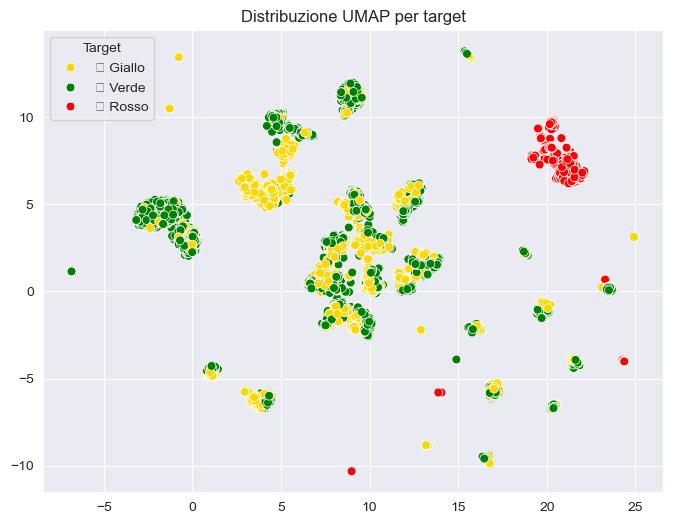

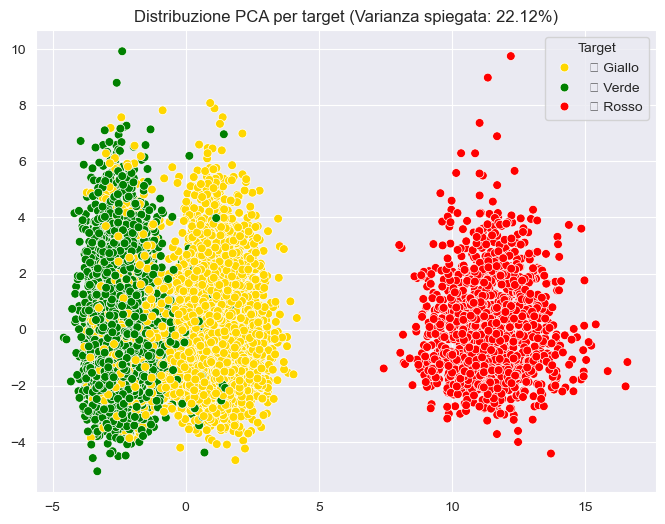

In [41]:
from collections import Counter
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


NGRAM_N = 3
TOP_K_NGRAMS = 3000
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
RANDOM_STATE = 42


# -----------------------------
# Funzioni ausiliarie
# -----------------------------
def discretize_duration_by_state(state, dur, thresholds):
    """
    Discretizza la durata di uno stato in breve (N) o lunga (L) rispetto alla soglia specifica.
    """
    thr = thresholds.get(state, 30)
    return "N" if dur < thr else "L"


def build_ngram_vocab(sequences, n=NGRAM_N, top_k=TOP_K_NGRAMS):
    """
    Costruisce il vocabolario dei n-gram più frequenti da una lista di sequenze.
    """
    counter = Counter()
    for seq in tqdm(sequences, desc="Conteggio n-gram"):
        if len(seq) < n:
            continue
        states = [s for s, _, _ in seq]
        durs = [discretize_duration_by_state(s, d, THRESHOLDS_DURATION) for s, d, _ in seq]
        # Genera n-gram e aggiorna contatore
        for i in range(len(seq) - n + 1):
            ng = "_".join(f"{st}({du})" for st, du in zip(states[i:i + n], durs[i:i + n]))
            counter[ng] += 1
    # Restituisce solo i top_k n-gram più frequenti
    return [ng for ng, _ in counter.most_common(top_k)]


def sequences_to_sparse_matrix(sequences, vocab, n=NGRAM_N):
    """
    Trasforma le sequenze in una matrice sparsa n-gram (conteggio frequenze).
    """
    vocab_index = {ng: i for i, ng in enumerate(vocab)}
    row_idx, col_idx, data = [], [], []

    for seq_id, seq in enumerate(tqdm(sequences, desc="Vettorizzazione")):
        if len(seq) < n:
            continue
        states = [s for s, _, _ in seq]
        durs = [discretize_duration_by_state(s, d, THRESHOLDS_DURATION) for s, d, _ in seq]
        counts = Counter()
        for i in range(len(seq) - n + 1):
            ng = "_".join(f"{st}({du})" for st, du in zip(states[i:i + n], durs[i:i + n]))
            if ng in vocab_index:
                counts[vocab_index[ng]] += 1
        for col, c in counts.items():
            row_idx.append(seq_id)
            col_idx.append(col)
            data.append(c)

    return csr_matrix((data, (row_idx, col_idx)), shape=(len(sequences), len(vocab)))


def analyze_distribution_by_target(df, n=NGRAM_N, top_k=TOP_K_NGRAMS):
    """
    Analizza la distribuzione delle sequenze per target usando UMAP e PCA.
    """
    if df.empty:
        print("Dataset vuoto.")
        return

    sequences = df["sequence"].tolist()
    print(f"Numero sequenze: {len(sequences)}")

    # 1. Costruzione vocabolario n-gram
    vocab = build_ngram_vocab(sequences, n=n, top_k=top_k)
    print(f"Vocabolario n-gram: {len(vocab)} termini")

    # 2. Creazione matrice sparsa
    X_sparse = sequences_to_sparse_matrix(sequences, vocab, n=n)
    print(f"Shape matrice sparsa: {X_sparse.shape}")

    # 3. Standardizzazione
    scaler = StandardScaler(with_mean=False)
    X_scaled = scaler.fit_transform(X_sparse)

    # 4. UMAP embedding
    print("Eseguo UMAP...")
    reducer = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_STATE
    )
    emb_umap = reducer.fit_transform(X_scaled)

    # 5. PCA embedding
    print("Eseguo PCA (2 componenti)...")
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    emb_pca = pca.fit_transform(X_scaled.toarray())
    explained_var = pca.explained_variance_ratio_.sum()
    print(f"Varianza spiegata PCA: {explained_var:.2%}")

    # 6. Palette dinamica
    palette = {}
    for t in df["target"].unique():
        if "rosso" in t.lower() or "🔴" in t:
            palette[t] = "red"
        elif "giallo" in t.lower() or "🟡" in t:
            palette[t] = "gold"
        elif "verde" in t.lower() or "🟢" in t:
            palette[t] = "green"

    # 7. Visualizzazione UMAP
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=emb_umap[:, 0], y=emb_umap[:, 1], hue=df["target"], palette=palette, s=40)
    plt.title("Distribuzione UMAP per target")
    plt.legend(title="Target")
    plt.show()

    # 8. Visualizzazione PCA
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=emb_pca[:, 0], y=emb_pca[:, 1], hue=df["target"], palette=palette, s=40)
    plt.title(f"Distribuzione PCA per target (Varianza spiegata: {explained_var:.2%})")
    plt.legend(title="Target")
    plt.show()

    return {"emb_umap": emb_umap, "emb_pca": emb_pca, "palette": palette}


results_all = analyze_distribution_by_target(df_long, n=3, top_k=3000)

# DETECTION PATTERN (N-GRAM)
-Globale su sequenze generale

-Specifio per csv paziente

In [19]:

import pickle


def is_two_state_alternating(pattern):
    """
    True se pattern è tipo:
    A, B, A, B, A ...
    o B, A, B, A, B ...
    Anche con durate: 'VP(N)' -> 'VP'
    """
    def clean_state(x):
        return x.split("(")[0]

    cleaned = [clean_state(p) for p in pattern]
    unique_states = list(set(cleaned))

    # Deve contenere esattamente due stati
    if len(unique_states) != 2:
        return False

    # Alternanza perfetta
    exp1 = [unique_states[i % 2] for i in range(len(cleaned))]
    exp2 = [unique_states[(i + 1) % 2] for i in range(len(cleaned))]

    return cleaned == exp1 or cleaned == exp2


# =========================================================
#  FUNZIONI BASE
# =========================================================
def csv_to_sequence(csv_path):
    df = pd.read_csv(csv_path)
    df["duration_minutes"] = pd.to_timedelta(df["Duration"]).dt.total_seconds() / 60
    return df[["Event", "duration_minutes"]].values.tolist()


def discretize_duration_by_state(state, duration, THRESHOLDS_DURATION=None):
    if not THRESHOLDS_DURATION or state not in THRESHOLDS_DURATION:
        return ""
    thr = THRESHOLDS_DURATION[state]
    if isinstance(thr, (list, tuple)):
        thr = thr[0]
    return "L" if duration > thr else "N"


def normalize_sequence(sequence):
    seq_full = []
    for item in sequence:
        if isinstance(item, np.ndarray):
            item = item.tolist()
        if len(item) == 2:
            s, d = item
            seq_full.append((s, d, 0.0))
        elif len(item) == 3:
            seq_full.append(tuple(item))
        else:
            raise ValueError(f"Formato non supportato: {item}")
    return seq_full


def extract_ngrams(sequence, n_list=[4,5], use_duration=False, THRESHOLDS_DURATION=None):
    seq = normalize_sequence(sequence)
    states = [s for s, d, g in seq]
    durations = [
        discretize_duration_by_state(s, d, THRESHOLDS_DURATION) if (use_duration and THRESHOLDS_DURATION) else ""
        for s, d, g in seq
    ]

    ngrams = []
    for n in n_list:
        for i in range(len(seq) - n + 1):
            ng = tuple(
                f"{st}({du})" if du else st
                for st, du in zip(states[i:i+n], durations[i:i+n])
            )
            ngrams.append(ng)
    return ngrams


# =========================================================
#  PATTERN GLOBALI (con filtro anti-alternanza)
# =========================================================
def build_detection_patterns(df, n_list=[4,5], top_k=50, use_duration=False, THRESHOLDS_DURATION=None, cache_dir="pattern_cache"):

    os.makedirs(cache_dir, exist_ok=True)
    hash_str = f"{hash(tuple(n_list))}_{top_k}_{use_duration}_{str(THRESHOLDS_DURATION)}"
    cache_path = os.path.join(cache_dir, f"detection_patterns_{abs(hash(hash_str))}.pkl")

    # Cache
    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    all_patterns = []

    for n in n_list:
        print(f"\n--- Estrazione pattern globali per n={n} ---")
        targets = df["target"].unique()
        pattern_counts = {}
        total_counts = {}

        for target in targets:
            seqs = df[df["target"] == target]["sequence"].tolist()
            ngrams = []

            for seq in tqdm(seqs, desc=f"Target {target}"):
                raw_ngrams = extract_ngrams(seq, n_list=[n], use_duration=use_duration, THRESHOLDS_DURATION=THRESHOLDS_DURATION)

                # Filtro pattern alternati
                filtered = [ng for ng in raw_ngrams if not is_two_state_alternating(ng)]

                ngrams.extend(filtered)

            pattern_counts[target] = Counter(ngrams)
            total_counts[target] = sum(pattern_counts[target].values())

        # ---- Costruzione DF globale ----
        all_keys = set()
        for c in pattern_counts.values():
            all_keys.update(c.keys())

        rows = []
        for pat in all_keys:
            row = {"pattern": pat, "n": n}
            lift_vals = {}

            for target in targets:
                cnt = pattern_counts[target].get(pat, 0)
                freq_t = cnt / total_counts[target] if total_counts[target] else 0

                cnt_others = sum(pattern_counts[t].get(pat, 0) for t in targets if t != target)
                total_others = sum(total_counts[t] for t in targets if t != target)

                freq_o = cnt_others / total_others if total_others else 1e-9
                lift = freq_t / freq_o if freq_o else 0

                row[f"freq_{target}"] = freq_t
                row[f"lift_{target}"] = lift
                lift_vals[target] = lift

            row["dominant_target"] = max(lift_vals, key=lift_vals.get)
            row["max_lift"] = lift_vals[row["dominant_target"]]
            rows.append(row)

        df_n = pd.DataFrame(rows).sort_values("max_lift", ascending=False).head(top_k)
        all_patterns.append(df_n)

    detection_patterns = (
        pd.concat(all_patterns, ignore_index=True)
        .sort_values("max_lift", ascending=False)
        .reset_index(drop=True)
    )

    with open(cache_path, "wb") as f:
        pickle.dump(detection_patterns, f)

    return detection_patterns


# =========================================================
#  HEATMAP
# =========================================================
def plot_detection_patterns_heatmap(detection_patterns, targets, metric="freq"):
    metric = metric.lower()
    columns = [f"{metric}_{t}" for t in targets]
    heatmap_data = detection_patterns[columns]
    heatmap_data.index = detection_patterns["pattern"].astype(str)
    plt.figure(figsize=(12, max(4,len(heatmap_data)*0.5)))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f"Distribuzione {metric.upper()} dei pattern")
    plt.show()


# =========================================================
#  PATTERN PAZIENTE (con filtro)
# =========================================================
def extract_patient_patterns(sequence, n_list=[4,5], top_k=20, use_duration=False, THRESHOLDS_DURATION=None):
    raw = extract_ngrams(sequence, n_list=n_list, use_duration=use_duration, THRESHOLDS_DURATION=THRESHOLDS_DURATION)

    #  filtro alternanza
    filtered = [ng for ng in raw if not is_two_state_alternating(ng)]

    freq = Counter(filtered)
    df = pd.DataFrame([{"pattern":k,"freq_paziente":v} for k,v in freq.items()]).sort_values("freq_paziente", ascending=False)
    return df.head(top_k)


# =========================================================
#  CONFRONTO PAZIENTE vs GLOBALI
# =========================================================
def patient_vs_global_patterns_from_df(df_patient, detection_patterns):

    df_patient = df_patient.copy()
    global_dict = detection_patterns.set_index("pattern").to_dict(orient="index")

    dom, freq_g, lift_g = [], [], []

    for pat in df_patient["pattern"]:
        if pat in global_dict:
            row = global_dict[pat]
            targ = row["dominant_target"]
            dom.append(targ)
            freq_g.append(row[f"freq_{targ}"])
            lift_g.append(row[f"lift_{targ}"])
        else:
            dom.append(None)
            freq_g.append(0.0)
            lift_g.append(0.0)

    df_patient["dominant_target_global"] = dom
    df_patient["freq_global"] = freq_g
    df_patient["lift_global"] = lift_g

    return df_patient

Distribuzione dei target nel dataset:
🟢 Verde: 1646 sequenze (54.9%)
🟡 Giallo: 1058 sequenze (35.3%)
🔴 Rosso: 296 sequenze (9.9%)
[INFO] BUILD PATTERN GLOBALI SENZA DURATA

--- Estrazione pattern globali per n=4 ---


Target 🔴 Rosso: 100%|██████████| 296/296 [00:00<00:00, 887.48it/s]



--- Estrazione pattern globali per n=5 ---


Target 🔴 Rosso: 100%|██████████| 296/296 [00:00<00:00, 757.68it/s]


,pattern,n,freq_🟢 Verde,lift_🟢 Verde,freq_🟡 Giallo,lift_🟡 Giallo,freq_🔴 Rosso,lift_🔴 Rosso,dominant_target,max_lift
0,"(extremely_high, high, normal, low, extremely_...",5,0.001771,0.212979,0.004566,0.851655,0.018273,6.175400,🔴 Rosso,6.175400
1,"(extremely_high, high, normal, high, extremely...",5,0.002190,0.236286,0.005027,0.812992,0.020538,6.048696,🔴 Rosso,6.048696
2,"(extremely_low, low, extremely_low, low, normal)",5,0.003084,0.195436,0.009053,0.929561,0.033663,5.988713,🔴 Rosso,5.988713
3,"(normal, low, extremely_low, low, extremely_low)",5,0.003083,0.195618,0.009045,0.930079,0.033603,5.982675,🔴 Rosso,5.982675
4,"(extremely_high, high, extremely_high, high, n...",5,0.004035,0.230869,0.009644,0.839371,0.038293,5.965422,🔴 Rosso,5.965422
5,"(normal, high, extremely_high, high, extremely...",5,0.004042,0.231145,0.009661,0.840367,0.038293,5.954893,🔴 Rosso,5.954893
6,"(extremely_low, low, normal, high, extremely_h...",5,0.001790,0.214506,0.004766,0.901198,0.017863,5.847232,🔴 Rosso,5.847232
7,"(extremely_low, low, normal, low, extremely_low)",5,0.001247,0.173874,0.004332,1.037092,0.014713,5.751380,🔴 Rosso,5.751380
8,"(high, normal, low, extremely_low, low)",5,0.015656,0.538417,0.024642,1.165477,0.040869,2.098500,🔴 Rosso,2.098500
9,"(low, extremely_low, low, normal, low)",5,0.011690,0.477094,0.021277,1.301887,0.033073,2.097919,🔴 Rosso,2.097919


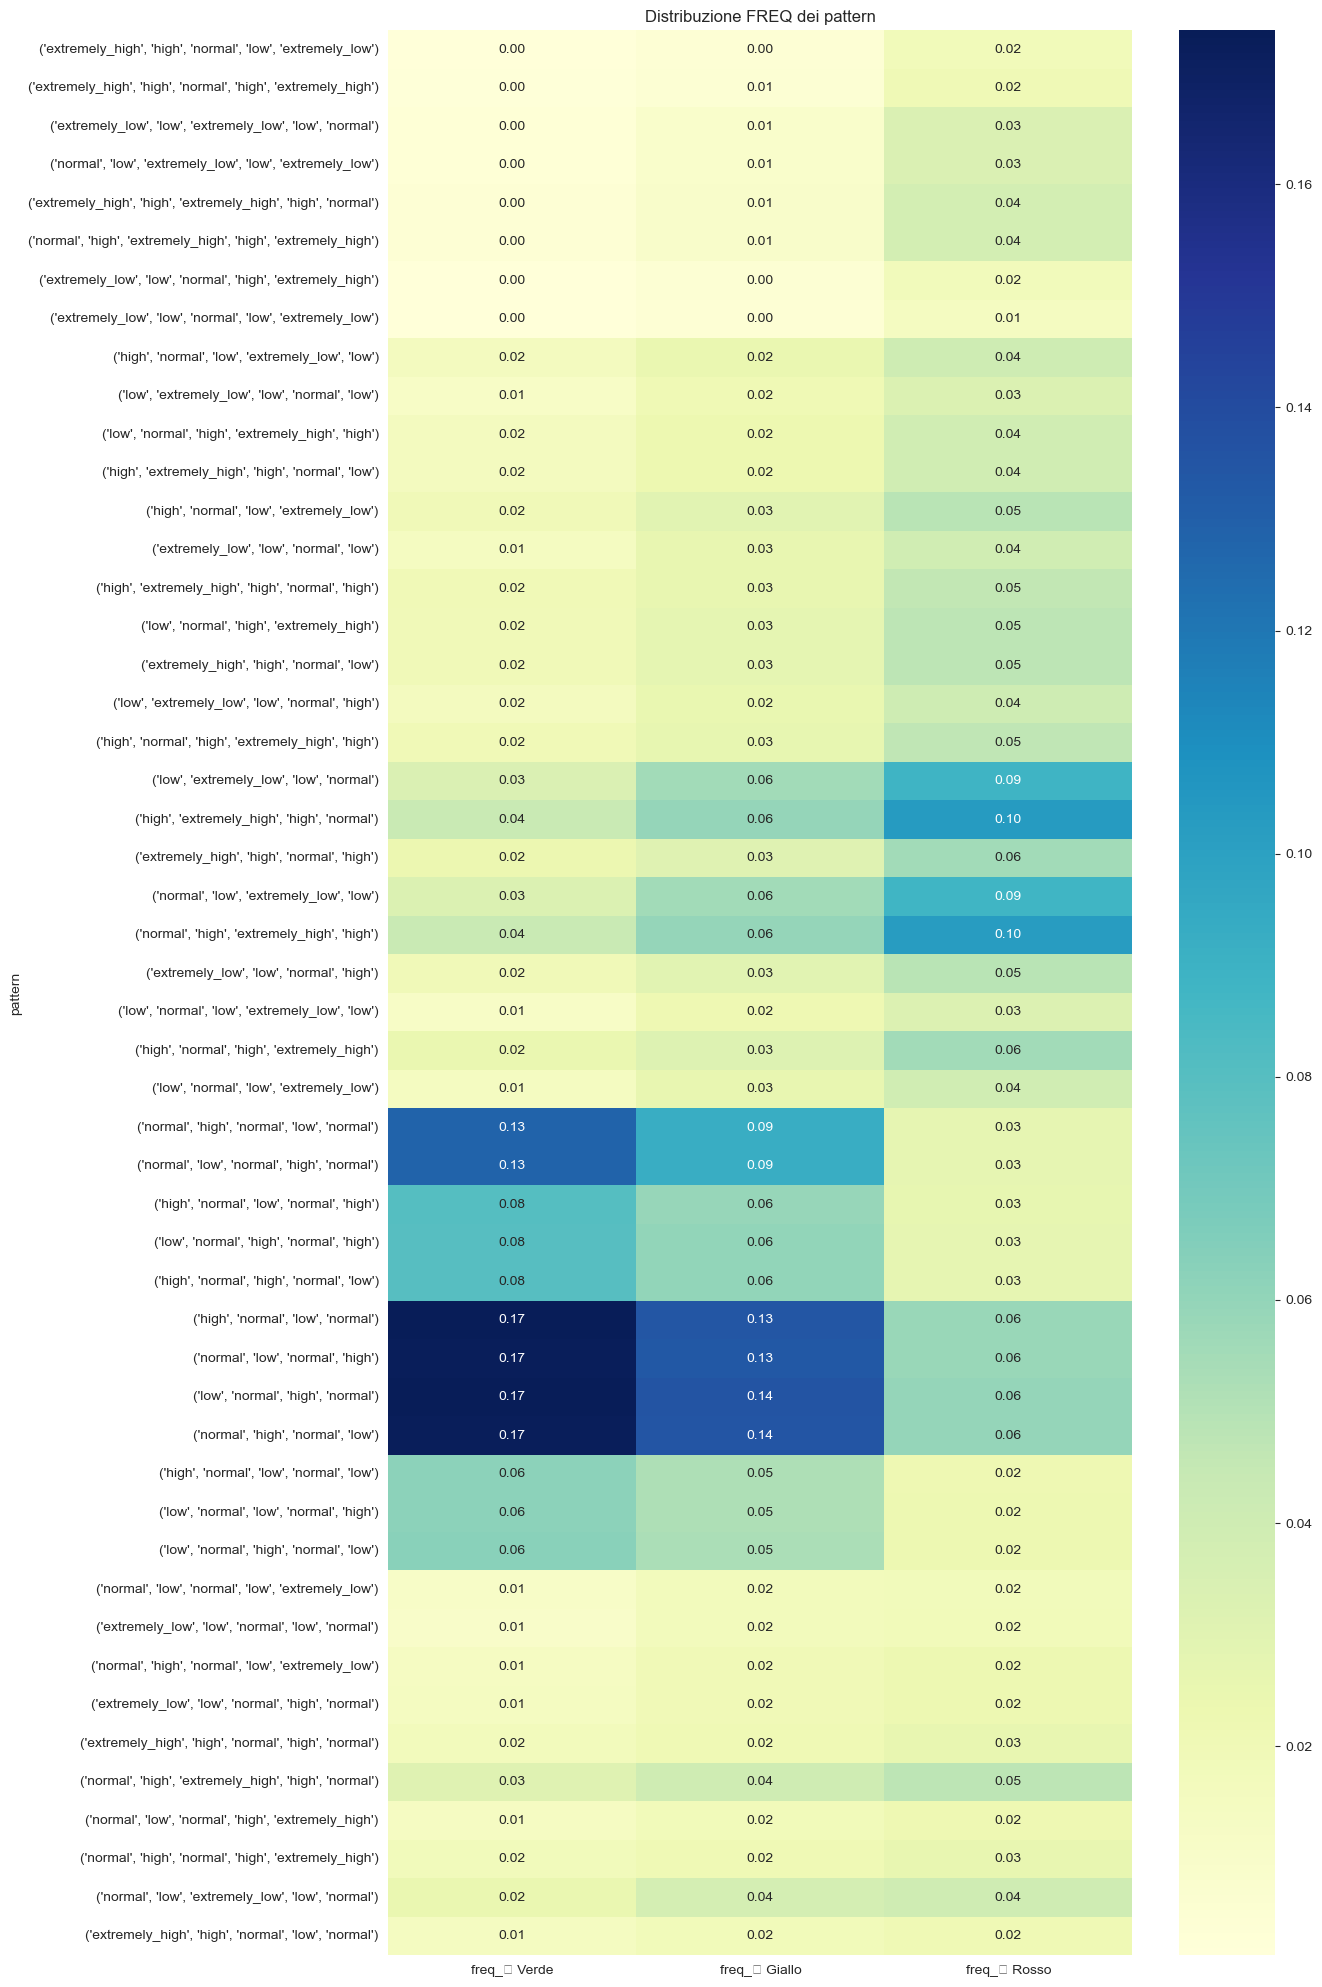

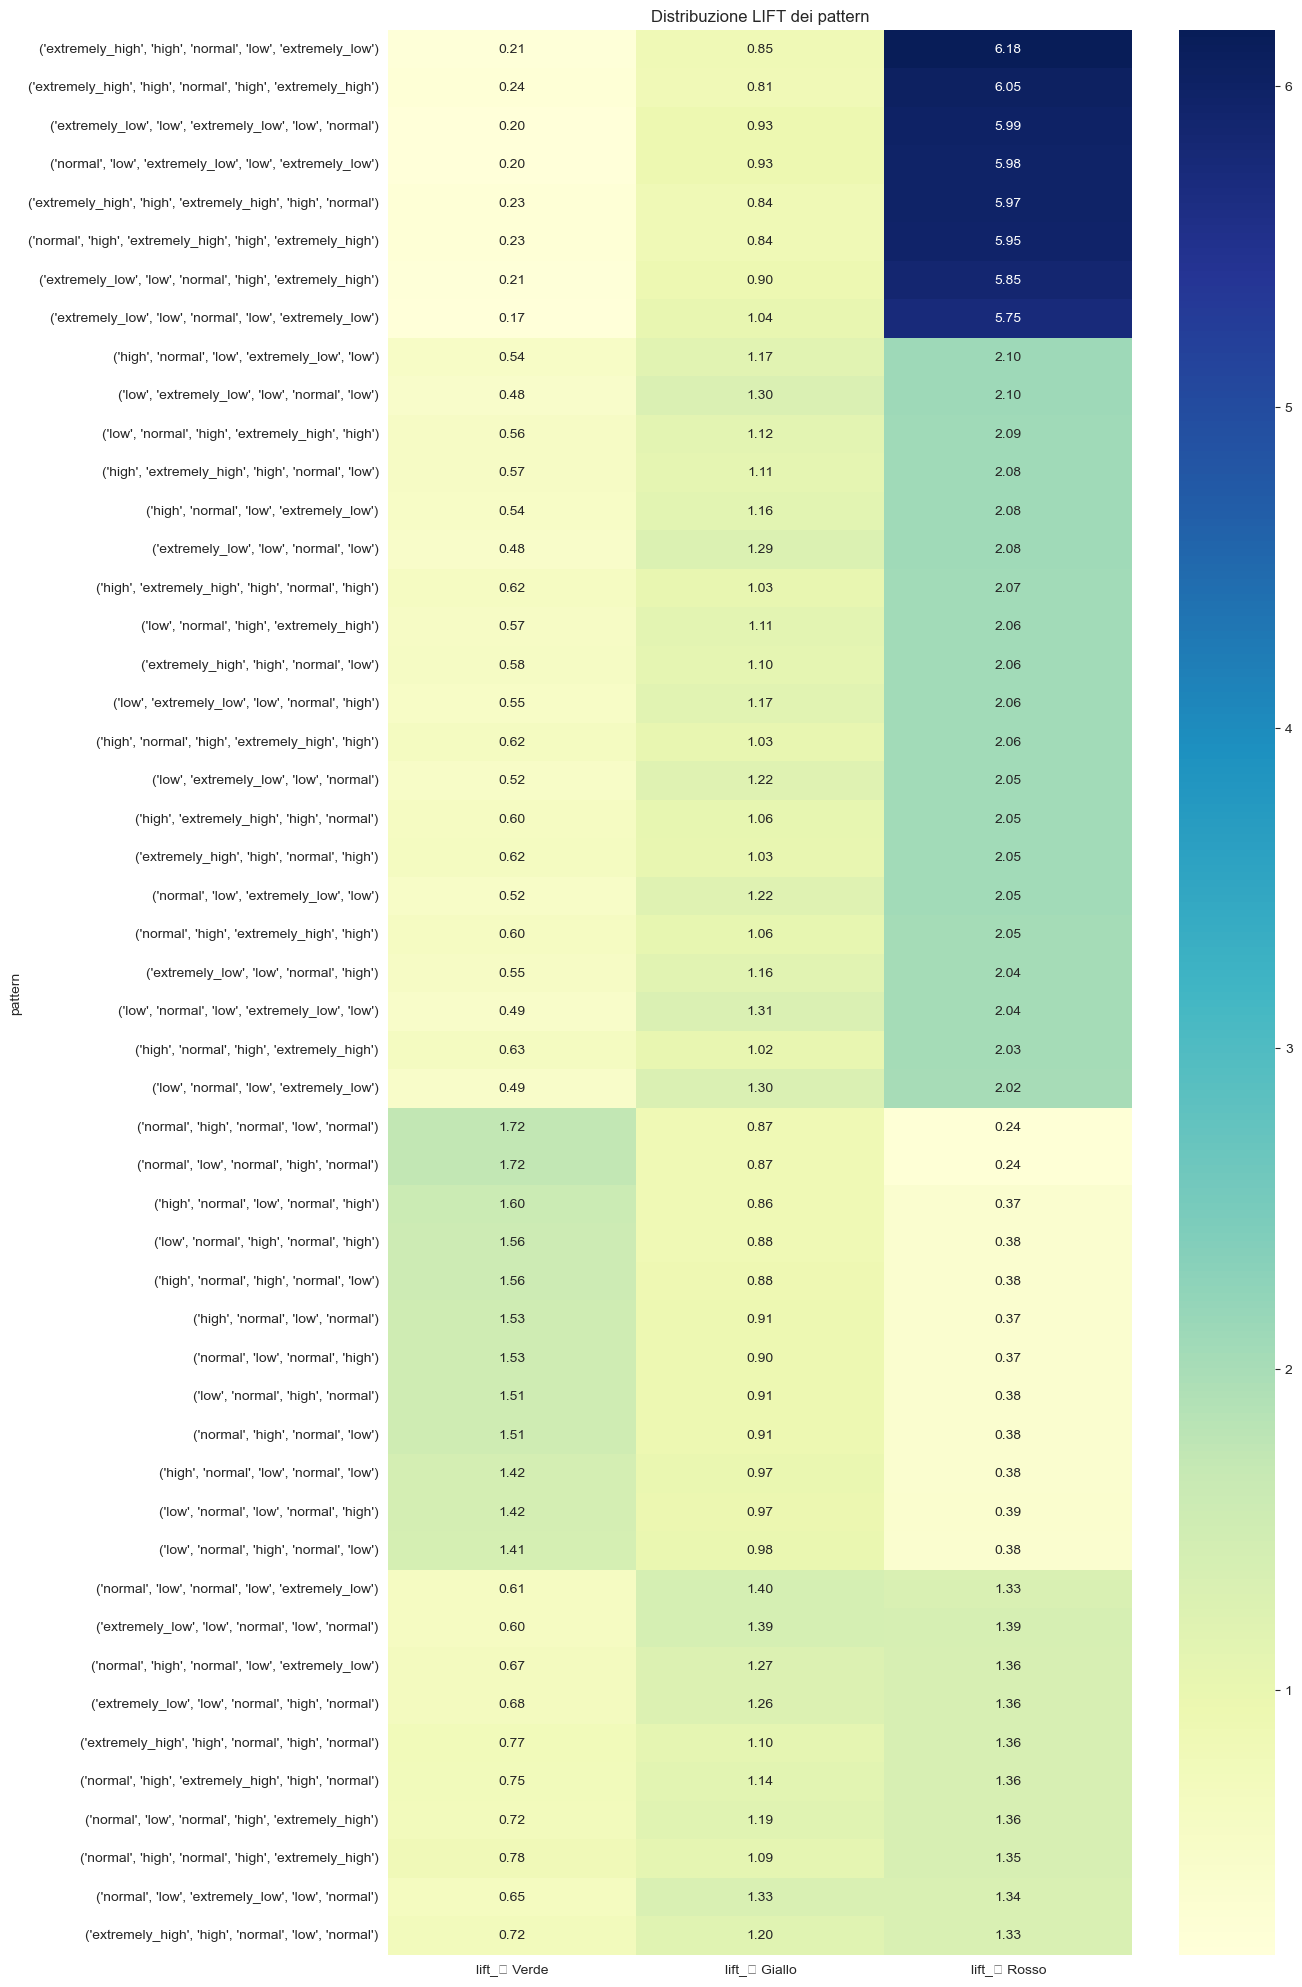

[INFO] PATTERN PAZIENTE SENZA DURATA
[INFO] CONFRONTO PATTERN PAZIENTE VS GLOBALI (SENZA DURATA)


,pattern,freq_paziente,dominant_target_global,freq_global,lift_global
9,"(normal, high, extremely_high, high)",32,🔴 Rosso,0.102934,2.049170
10,"(high, extremely_high, high, normal)",31,🔴 Rosso,0.103176,2.053336
41,"(normal, high, extremely_high, high, normal)",20,🔴 Rosso,0.047666,1.358195
28,"(low, normal, high, extremely_high, high)",18,🔴 Rosso,0.039439,2.085452
12,"(high, normal, low, normal)",18,🟢 Verde,0.173804,1.532990
8,"(low, normal, high, extremely_high)",18,🔴 Rosso,0.047223,2.063515
39,"(high, extremely_high, high, normal, low)",17,🔴 Rosso,0.039592,2.080472
13,"(normal, low, normal, high)",17,🟢 Verde,0.172817,1.531611
15,"(extremely_high, high, normal, low)",17,🔴 Rosso,0.047386,2.060298
31,"(high, extremely_high, high, normal, high)",14,🔴 Rosso,0.046334,2.072656


In [24]:
#df_long_path = "prepared_ml_datasets/df_long.pkl"
#df_long = pd.read_pickle(df_long_path)
df_long = generate_simulated_sequences(G, num_sequences=3000, total_days=45)
# --- Pattern globali ---
print("[INFO] BUILD PATTERN GLOBALI SENZA DURATA")
detection_patterns_no_duration = build_detection_patterns(df_long, n_list=[4,5], top_k=200, use_duration=False)
display(detection_patterns_no_duration)
plot_detection_patterns_heatmap(detection_patterns_no_duration, df_long["target"].unique(), metric="freq")
plot_detection_patterns_heatmap(detection_patterns_no_duration, df_long["target"].unique(), metric="lift")

#print("[INFO] BUILD PATTERN GLOBALI CON DURATA")
#detection_patterns_with_duration = build_detection_patterns(df_long, n_list=[4,5], top_k=50, use_duration=True, THRESHOLDS_DURATION=THRESHOLDS_DURATION)
#display(detection_patterns_with_duration)
#plot_detection_patterns_heatmap(detection_patterns_with_duration, df_long["target"].unique(), metric="freq")
#plot_detection_patterns_heatmap(detection_patterns_with_duration, df_long["target"].unique(), metric="lift")

# --- Pattern paziente ---
sequence_pz = csv_to_sequence("simulated_intervals/rosso_labeling.csv")

print("[INFO] PATTERN PAZIENTE SENZA DURATA")
patient_patterns_no_duration = extract_patient_patterns(sequence_pz, n_list=[4,5], top_k=10, use_duration=False)
#display(patient_patterns_no_duration)

#print("[INFO] PATTERN PAZIENTE CON DURATA")
#patient_patterns_with_duration = extract_patient_patterns(sequence_pz, n_list=[4,5], top_k=10, use_duration=True, THRESHOLDS_DURATION=THRESHOLDS_DURATION)
#display(patient_patterns_with_duration)

# --- Confronto paziente vs globali ---
report_no_duration = patient_vs_global_patterns_from_df(patient_patterns_no_duration, detection_patterns_no_duration)
#report_with_duration = patient_vs_global_patterns_from_df(patient_patterns_with_duration, detection_patterns_with_duration)

print("[INFO] CONFRONTO PATTERN PAZIENTE VS GLOBALI (SENZA DURATA)")
display(report_no_duration)

#print("[INFO] CONFRONTO PATTERN PAZIENTE VS GLOBALI (CON DURATA)")
#display(report_with_duration)

In [34]:
report_no_duration.iloc[0:, 0:]

,pattern,freq_paziente,dominant_target_global,freq_global,lift_global
9,"(normal, high, extremely_high, high)",32,🔴 Rosso,0.103364,1.912490
10,"(high, extremely_high, high, normal)",31,🔴 Rosso,0.103481,1.914168
41,"(normal, high, extremely_high, high, normal)",20,🔴 Rosso,0.047370,1.269486
28,"(low, normal, high, extremely_high, high)",18,🔴 Rosso,0.039521,1.926016
12,"(high, normal, low, normal)",18,🟢 Verde,0.167603,1.516901
8,"(low, normal, high, extremely_high)",18,🔴 Rosso,0.047347,1.909557
39,"(high, extremely_high, high, normal, low)",17,🔴 Rosso,0.039586,1.932927
13,"(normal, low, normal, high)",17,🟢 Verde,0.167072,1.516977
15,"(extremely_high, high, normal, low)",17,🔴 Rosso,0.047384,1.916797
31,"(high, extremely_high, high, normal, high)",14,🔴 Rosso,0.046658,1.930704
